In [48]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Task 7

In [49]:
Q = np.array([
    [-0.0085,  0.005,  0.0025,  0,      0.001],
    [ 0,      -0.014,  0.005,   0.004,  0.005],
    [ 0,       0,     -0.008,   0.003,  0.005],
    [ 0,       0,      0,      -0.009,  0.009],
    [ 0,       0,      0,       0,      0    ]
])

rng = np.random.default_rng(30)
times = []
state_2_count = 0

for i in range(1_000):
    # Initial parameters
    curr_state = 0
    total_time = 0
    reached_state_2_after_30_5 = 0

    while True:
        # Exclude current state as next possible state
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        # Draw transition time
        q = Q[curr_state,curr_state]
        time = rng.exponential(-1/q)

        # Create poperbilities
        props = Q[curr_state, possible_states] / -q

        # Draw next state
        new_state = rng.choice(possible_states, p=props)

        # Update total time
        total_time += time

        # Check if state 4 (death)
        if new_state == 4:
            break

        # Check state 2 count
        if (new_state == 2) and (total_time > 30.5):
            reached_state_2_after_30_5 = 1

        curr_state = new_state

    state_2_count += reached_state_2_after_30_5

    times.append(total_time)

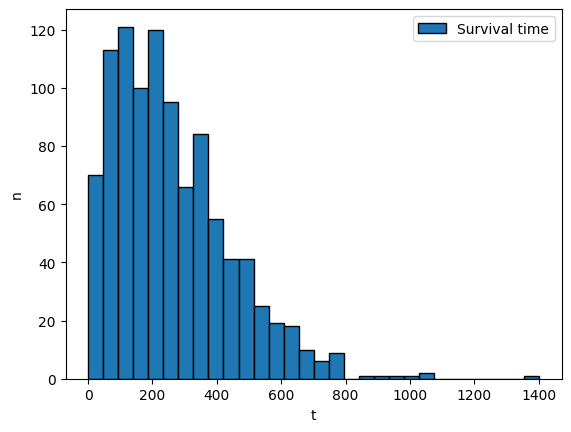

In [50]:
plt.hist(times,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("t")
plt.legend()
plt.show()

In [51]:
xbar = np.mean(times)
s = np.std(times, ddof=1)
SE = s/np.sqrt(1_000)
ME = ss.norm.ppf(0.975)

print(f"Mean: {xbar}")
print(f"Standard deviation: {s}")
print(f"Confidence interval: {xbar - ME*SE}, {xbar + ME*SE}")
print(f"proportion of women has the cancer reappeared distantly after 30.5 months: {state_2_count/1_000}")

Mean: 260.6557758370406
Standard deviation: 182.5444358603559
Confidence interval: 249.34176238493188, 271.96978928914933
proportion of women has the cancer reappeared distantly after 30.5 months: 0.43


# Task 8

In [52]:
from scipy.linalg import expm

Qs = Q[:-1,:-1]
p0 = np.array([1,0,0,0])

# Theoretical cdf
Ft = lambda t: 1 - p0 @ expm(Qs*t) @ np.ones(len(p0)) 
theoretical_cdf = [Ft(t) for t in np.linspace(0,1400,2000)]

# Emperiacal cdf
ecdf = ss.ecdf(times)


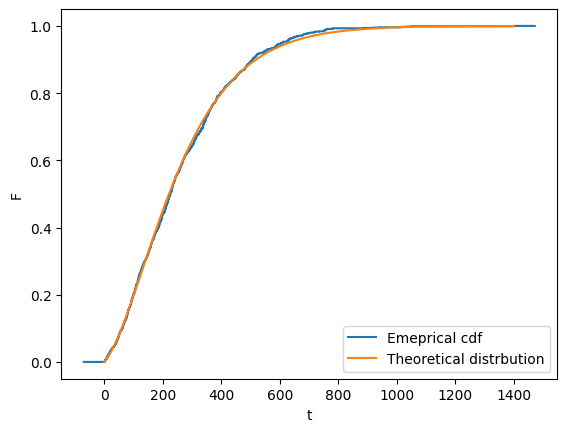

In [53]:
ecdf.cdf.plot(label="Emeprical cdf")
plt.plot(np.linspace(0,1400,2000), theoretical_cdf, label="Theoretical distrbution")
plt.ylabel("F")
plt.xlabel("t")
plt.legend()
plt.show()

# Task 9

In [54]:
# Calculate the diaganoal
q11 = -np.sum([0.0025, 0.00125, 0, 0.001])
q22 = -np.sum([0, 0.002, 0.005])
q33 = -np.sum([0.003, 0.005])
q44 = -np.sum([0.009])
q55 = 0

Q = np.array([
    [q11, 0.0025, 0.00125, 0, 0.001],
    [0, q22, 0, 0.002, 0.005],
    [0, 0, q33, 0.003, 0.005],
    [0, 0, 0, q44, 0.009],
    [0, 0, 0, 0, q55]
])

In [55]:
rng = np.random.default_rng(30)
times2 = []
state_2_count = 0

for i in range(1_000):
    # Initial parameters
    curr_state = 0
    total_time = 0
    reached_state_2_after_30_5 = 0

    while True:
        # Exclude current state as next possible state
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        # Draw transition time
        q = Q[curr_state,curr_state]
        time = rng.exponential(-1/q)

        # Create poperbilities
        props = Q[curr_state, possible_states] / -q

        # Draw next state
        new_state = rng.choice(possible_states, p=props)

        # Update total time
        total_time += time

        # Check if state 4 (death)
        if new_state == 4:
            break

        # Check state 2 count
        if (new_state == 2) and (total_time > 30.5):
            reached_state_2_after_30_5 = 1

        curr_state = new_state

    state_2_count += reached_state_2_after_30_5

    times2.append(total_time)

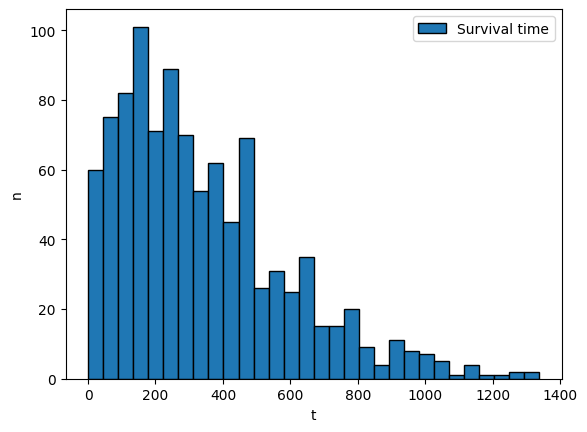

Mean: 339.7750489830864
Standard deviation: 249.67858023382516
Confidence interval: 324.3000946129083, 355.25000335326445
proportion of women has the cancer reappeared distantly after 30.5 months: 0.23


In [59]:
plt.hist(times2,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("t")
plt.legend()
plt.show()

xbar = np.mean(times2)
s = np.std(times2, ddof=1)
SE = s/np.sqrt(1_000)
ME = ss.norm.ppf(0.975)

print(f"Mean: {xbar}")
print(f"Standard deviation: {s}")
print(f"Confidence interval: {xbar - ME*SE}, {xbar + ME*SE}")
print(f"proportion of women has the cancer reappeared distantly after 30.5 months: {state_2_count/1_000}")

In [57]:
def kaplan_meyer(obs, t):
    dt = np.sum(obs < t)
    return (1_000 - dt) / 1_000

In [60]:
t_interval = np.linspace(0,1400,2000)
kaplan_meyer1 = [kaplan_meyer(times, t) for t in t_interval]
kaplan_meyer2 = [kaplan_meyer(times2, t) for t in t_interval]

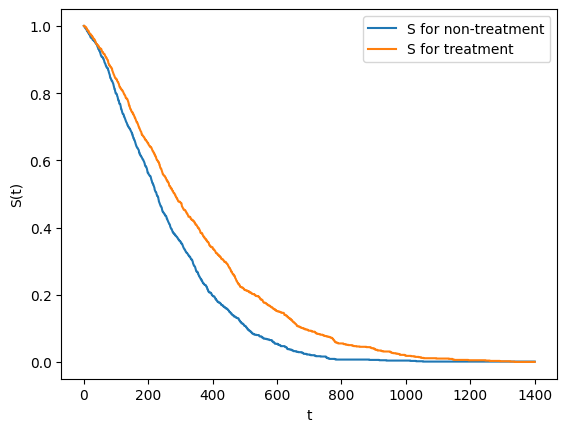

In [65]:
plt.plot(t_interval, kaplan_meyer1, label="S for non-treatment")
plt.plot(t_interval, kaplan_meyer2, label="S for treatment")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.legend()

# Task 10

In [69]:
logranktest = ss.logrank(times,times2)
print(logranktest.pvalue)

2.5228231367983424e-17
